# Feedforward Neural Network (FNN) classifier — Grace_WanjaB30299.ipynb

**GRACE WANJA BSDS 2:1**
**S24B38/009**

**Goal:** To train an FNN on `train_set1.csv`, evaluate on `test_set1.csv`, generate classification report & confusion matrix, plot training curves, save model as `model1.h5`.


In [4]:
#imports and reproducibility
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [5]:
# show cwd and files
import os
print("Current working dir:", os.getcwd())
print("Files here:", os.listdir('.'))


Current working dir: D:\AI TEST\Test 2 Data
Files here: ['.ipynb_checkpoints', 'Grace_WanjaB30299.ipynb', 'test_set1.csv', 'test_set2.csv', 'train_set1.csv', 'train_set2.csv']


In [6]:
train_path = "train_set1.csv"
test_path  = "test_set1.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (11340, 9)
Test shape: (2835, 9)


,F1,F2,F3,F4,F5,F6,F7,F8,target
0,-3.2268,-6.2389,-5.9290,-9.8005,-8.2025,-7.8455,-8.5810,-10.1000,3
1,-11.2050,-13.9080,-9.2148,-9.6139,-11.8650,-11.4180,-9.8571,-11.3570,5
2,32.3280,39.8740,35.8220,37.4360,34.7820,42.3790,40.4620,34.9660,4
3,31.3070,31.3120,39.1620,35.0400,29.1450,36.9030,39.4700,43.9160,4
4,3.4922,5.8438,6.3190,8.3182,6.8446,6.0096,4.7647,2.8718,1


## EDA & label handling
Check for missing values and see target distribution. 
If targets are not 0..K-1, we label-encode them.


In [7]:
# missing values
print("Missing values (train):\n", train_df.isna().sum())
print("Missing values (test):\n", test_df.isna().sum())

# target distribution
print("\nTrain target distribution:\n", train_df['target'].value_counts().sort_index())
print("\nTest target distribution:\n", test_df['target'].value_counts().sort_index())

# if target requires label encoding (e.g., classes are 1..K), encode to 0..K-1 for Keras compatibility
le = LabelEncoder()
y_train_raw = train_df['target'].values
y_test_raw  = test_df['target'].values

le.fit(np.concatenate([y_train_raw, y_test_raw]))
y_train = le.transform(y_train_raw)
y_test  = le.transform(y_test_raw)
class_names = [str(c) for c in le.classes_]
n_classes = len(class_names)
print("\nClasses (original):", le.classes_)
print("n_classes:", n_classes)


Missing values (train):
 F1        0
F2        0
F3        0
F4        0
F5        0
F6        0
F7        0
F8        0
target    0
dtype: int64
Missing values (test):
 F1        0
F2        0
F3        0
F4        0
F5        0
F6        0
F7        0
F8        0
target    0
dtype: int64

Train target distribution:
 target
1    1624
2    1633
3    1634
4    1598
5    1616
6    1627
7    1608
Name: count, dtype: int64

Test target distribution:
 target
1    390
2    411
3    403
4    424
5    391
6    401
7    415
Name: count, dtype: int64

Classes (original): [1 2 3 4 5 6 7]
n_classes: 7


## prepare features (scaling)
StandardScaler is used since FNN benefits from zero-mean unit-variance inputs.


In [8]:
X_train = train_df.drop(columns=['target']).values
X_test  = test_df.drop(columns=['target']).values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)


X_train shape: (11340, 8)


Designing and justifying the model (FNN)
**Model architecture (chosen):**
- Input: 8 features  
- Dense(64, ReLU) — **why**: wide first layer to allow learning many feature combinations  
- Dense(32, ReLU) — **why**: bottleneck to force hierarchical feature abstraction  
- Dense(16, ReLU) — **why**: further abstraction before output  
- Dense(n_classes, softmax) — output layer for multi-class classification  

**Hyperparameters (chosen & justification):**
- Optimizer: `Adam` (adaptive, good default for many problems)
- Learning rate: default Adam lr=0.001 (robust starting point)
- Loss: `sparse_categorical_crossentropy` (labels are integer encoded)
- Batch size: 16 (small-to-medium; works well for modest datasets)
- Epochs: 100 with EarlyStopping (patience=10) to prevent overfitting
- Validation split: 0.2 (use part of training set for validation)
- Callbacks: EarlyStopping + ModelCheckpoint to save best model


In [10]:
#building the model
input_shape = X_train.shape[1]

def build_model(input_shape, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ])
    return model

model = build_model(input_shape, n_classes)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,303 (12.90 KB)

 Trainable params: 3,303 (12.90 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# compiling + callbacks
LEARNING_RATE = 1e-3
BATCH_SIZE = 16
EPOCHS = 100

opt = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# callbacks
checkpoint_path = "best_model1.h5"
es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
mc = callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)


In [13]:
# training
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, mc],
    verbose=2
)


Epoch 1/100

Epoch 1: val_loss improved from None to 0.22857, saving model to best_model1.h5


567/567 - 10s - 18ms/step - accuracy: 0.5888 - loss: 0.9401 - val_accuracy: 0.9608 - val_loss: 0.2286
Epoch 2/100

Epoch 2: val_loss improved from 0.22857 to 0.10756, saving model to best_model1.h5


567/567 - 4s - 8ms/step - accuracy: 0.8941 - loss: 0.2796 - val_accuracy: 0.9691 - val_loss: 0.1076
Epoch 3/100

Epoch 3: val_loss improved from 0.10756 to 0.09216, saving model to best_model1.h5


567/567 - 4s - 8ms/step - accuracy: 0.9222 - loss: 0.2009 - val_accuracy: 0.9669 - val_loss: 0.0922
Epoch 4/100

Epoch 4: val_loss improved from 0.09216 to 0.08140, saving model to best_model1.h5


567/567 - 5s - 9ms/step - accuracy: 0.9313 - loss: 0.1709 - val_accuracy: 0.9696 - val_loss: 0.0814
Epoch 5/100

Epoch 5: val_loss improved from 0.08140 to 0.07284, saving model to best_model1.h5


567/567 - 5s - 9ms/step - accuracy: 0.9443 - loss: 0.1477 - val_accuracy: 0.9713 - val_loss: 0.0728
Epoch 6/100

Epoch 6: val_loss did not improve from 0.07284
567/567 - 6s - 10ms/step - accuracy: 0.9530 - loss: 0.1301 - val_accuracy: 0.9630 - val_loss: 0.0899
Epoch 7/100

Epoch 7: val_loss did not improve from 0.07284
567/567 - 5s - 8ms/step - accuracy: 0.9530 - loss: 0.1213 - val_accuracy: 0.9687 - val_loss: 0.0779
Epoch 8/100

Epoch 8: val_loss did not improve from 0.07284
567/567 - 4s - 8ms/step - accuracy: 0.9586 - loss: 0.1126 - val_accuracy: 0.9678 - val_loss: 0.0782
Epoch 9/100

Epoch 9: val_loss did not improve from 0.07284
567/567 - 5s - 9ms/step - accuracy: 0.9593 - loss: 0.1069 - val_accuracy: 0.9533 - val_loss: 0.1102
Epoch 10/100

Epoch 10: val_loss did not improve from 0.07284
567/567 - 4s - 7ms/step - accuracy: 0.9646 - loss: 0.1008 - val_accuracy: 0.9683 - val_loss: 0.0862
Epoch 11/100

Epoch 11: val_loss did not improve from 0.07284
567/567 - 4s - 7ms/step - accuracy:

In [14]:
# Save the final model and best checkpoint (best saved by ModelCheckpoint)kjlb 
model.save("model1.keras")  # preferred new format

print(" Final model saved as model1.keras")
print(" Best checkpoint already saved as:", checkpoint_path)



 Final model saved as model1.keras
 Best checkpoint already saved as: best_model1.h5


## visualization: training & validation curves
Plot loss and accuracy across epochs.


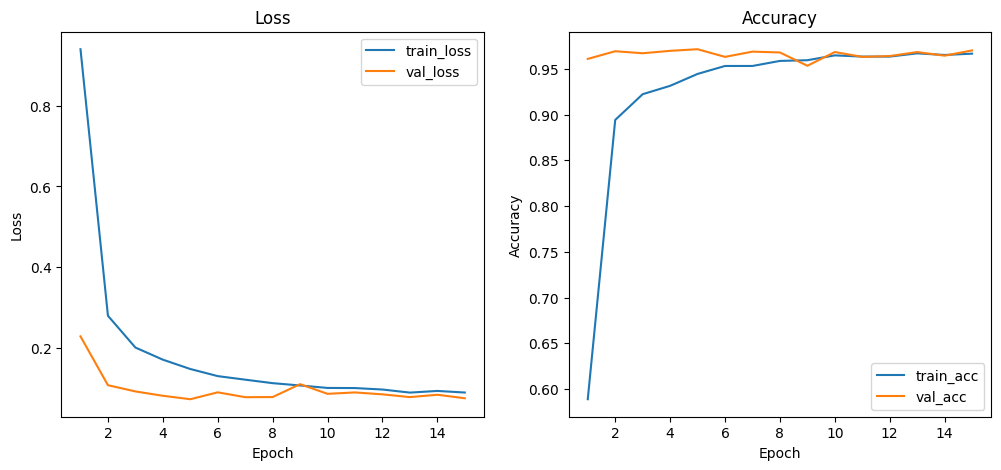

In [15]:
# Plot training history
hist = history.history
epochs_range = range(1, len(hist['loss'])+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, hist['loss'], label='train_loss')
plt.plot(epochs_range, hist['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(epochs_range, hist['accuracy'], label='train_acc')
plt.plot(epochs_range, hist['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()


## evaluate on test set: predictions, classification report, confusion matrix, class-wise accuracy


89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Test accuracy: 0.9753

Classification report:

              precision    recall  f1-score   support

           1     0.9897    0.9897    0.9897       390
           2     0.9976    0.9927    0.9951       411
           3     0.8947    0.9702    0.9310       403
           4     1.0000    1.0000    1.0000       424
           5     0.9664    0.8824    0.9225       391
           6     0.9826    0.9875    0.9851       401
           7     1.0000    1.0000    1.0000       415

    accuracy                         0.9753      2835
   macro avg     0.9759    0.9747    0.9748      2835
weighted avg     0.9762    0.9753    0.9753      2835



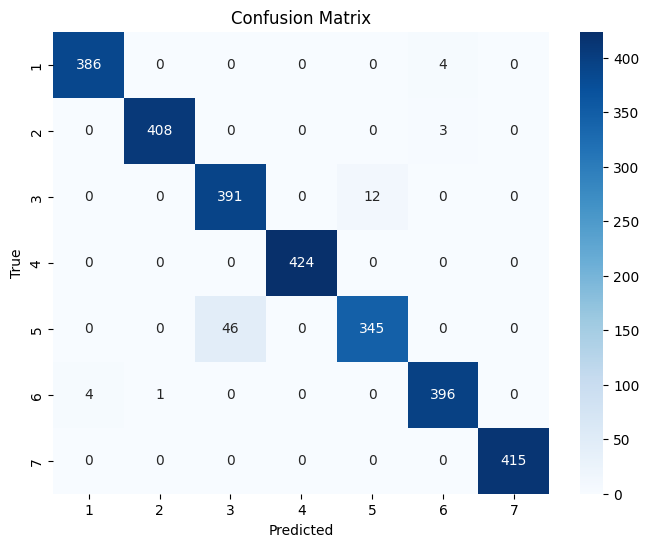

Class 1 accuracy: 0.9897
Class 2 accuracy: 0.9927
Class 3 accuracy: 0.9702
Class 4 accuracy: 1.0000
Class 5 accuracy: 0.8824
Class 6 accuracy: 0.9875
Class 7 accuracy: 1.0000


In [16]:
# predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# basic metrics
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}\n")

# classification report
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# class-wise accuracy (row-wise: correct / total for each true class)
class_wise_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc_cls in enumerate(class_wise_acc):
    print(f"Class {class_names[i]} accuracy: {acc_cls:.4f}")


In [17]:
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
report_df = pd.DataFrame({
    'class': class_names,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'support': support
})
report_df.to_csv("classification_report.csv", index=False)
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv("confusion_matrix.csv")
print("Saved classification_report.csv and confusion_matrix.csv")


Saved classification_report.csv and confusion_matrix.csv
